In [32]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer, KNNImputer, MissingIndicator
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder, MinMaxScaler, PowerTransformer, OrdinalEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression
from imblearn.pipeline import Pipeline # Use the imblearn pipeline
from imblearn.over_sampling import SMOTE

In [33]:
df = pd.read_csv('train.csv')
a2=df.copy()

In [34]:
a2.columns

Index(['customer_id', 'name', 'age', 'gender', 'owns_car', 'owns_house',
       'no_of_children', 'net_yearly_income', 'no_of_days_employed',
       'occupation_type', 'total_family_members', 'migrant_worker',
       'yearly_debt_payments', 'credit_limit', 'credit_limit_used(%)',
       'credit_score', 'prev_defaults', 'default_in_last_6months',
       'credit_card_default'],
      dtype='object')

In [35]:
# Dropping useless columns
a2 = a2.drop(columns=['customer_id',	'name','occupation_type','migrant_worker'])


In [36]:
X = a2.drop(columns='credit_card_default')
y = a2['credit_card_default']

In [37]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

Imputation Pipeline

In [38]:
features_to_fill_mode = ['owns_car']
features_to_fill_median = ['no_of_children','total_family_members']
features_to_fill_mean = ['no_of_days_employed','yearly_debt_payments','credit_score']

In [39]:
simple_imputer = ColumnTransformer(
    transformers=[
        ('mode_imputer', SimpleImputer(strategy='most_frequent'), features_to_fill_mode),
        ('median_imputer', SimpleImputer(strategy='median'), features_to_fill_median),
        ('mean_imputer', SimpleImputer(strategy='mean'), features_to_fill_mean)
    ],
    remainder='passthrough',  # leave other columns as they are
    n_jobs=-1,
    verbose_feature_names_out=False
)
simple_imputer.set_output(transform="pandas")

ColumnTransformer(n_jobs=-1, remainder='passthrough',
                  transformers=[('mode_imputer',
                                 SimpleImputer(strategy='most_frequent'),
                                 ['owns_car']),
                                ('median_imputer',
                                 SimpleImputer(strategy='median'),
                                 ['no_of_children', 'total_family_members']),
                                ('mean_imputer', SimpleImputer(),
                                 ['no_of_days_employed', 'yearly_debt_payments',
                                  'credit_score'])],
                  verbose_feature_names_out=False)

In [40]:
num_colss = ['age','no_of_children','net_yearly_income','no_of_days_employed','total_family_members','yearly_debt_payments','credit_limit','credit_limit_used(%)','credit_score']
nominal_cat_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()


In [42]:


preprocessor2 = ColumnTransformer(transformers=[
    ("scale", StandardScaler(), num_colss),
    ("nominal_encode", OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False), nominal_cat_cols),
], remainder="passthrough", n_jobs=-1, verbose_feature_names_out=False,)

preprocessor2.set_output(transform="pandas")


ColumnTransformer(n_jobs=-1, remainder='passthrough',
                  transformers=[('scale', StandardScaler(),
                                 ['age', 'no_of_children', 'net_yearly_income',
                                  'no_of_days_employed', 'total_family_members',
                                  'yearly_debt_payments', 'credit_limit',
                                  'credit_limit_used(%)', 'credit_score']),
                                ('nominal_encode',
                                 OneHotEncoder(drop='first',
                                               handle_unknown='ignore',
                                               sparse_output=False),
                                 ['gender', 'owns_car', 'owns_house'])],
                  verbose_feature_names_out=False)

In [11]:
%pip install xgboost


Note: you may need to restart the kernel to use updated packages.


In [43]:
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score
import optuna


from sklearn.metrics import f1_score

In [76]:
def objective(trial):
   
    model_name = trial.suggest_categorical("model", ["RF", "XGB", "SVC"])

    # Step B: Define the hyperparameter search space for each model
    if model_name == "SVC":
        c = trial.suggest_float("svc_c", 1e-3, 100, log=True)
        kernel = trial.suggest_categorical("svc_kernel", ["rbf", "poly"])
        model = SVC(C=c, kernel=kernel, probability=True, random_state=42)

    elif model_name == "RF":
        n_estimators = trial.suggest_int("rf_n_estimators", 50, 200)
        max_depth = trial.suggest_int("rf_max_depth", 2, 20)
        model = RandomForestClassifier(n_estimators=n_estimators, max_depth=max_depth, random_state=42, n_jobs=-1)

    elif model_name == "XGB":
        n_estimators = trial.suggest_int("xgb_n_estimators", 10, 200)
        learning_rate = trial.suggest_float("xgb_learning_rate", 0.01, 0.5, log=True)
        max_depth = trial.suggest_int("xgb_max_depth", 2, 20)
        model = XGBClassifier(n_estimators=n_estimators, learning_rate=learning_rate, max_depth=max_depth,
                              random_state=42, n_jobs=-1, eval_metric='logloss', use_label_encoder=False,enable_categorical=True)
        
   
 
    full_pipeline = Pipeline(steps=[
        ('imputer', simple_imputer),
        
        ('preprocessor',preprocessor2 ),
        ('smote', SMOTE(random_state=42)),
        ('classifier', model)
    ])

    skf = StratifiedKFold(n_splits=5,shuffle=True,random_state=42)

    scores = cross_val_score(full_pipeline, X_train, y_train, cv=skf, scoring='binary', n_jobs=-1)
    mean_score = scores.mean()

    return mean_score

In [53]:
# Optuna Study
print("\nStarting Optuna study to find the best model and hyperparameters...")
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=30)


print(f"Best trial's F1 score: {study.best_value}")
print("Best parameters found:")
for key, value in study.best_params.items():
    print(f"  {key}: {value}")

[I 2025-07-30 16:47:13,650] A new study created in memory with name: no-name-f4c4afe0-b074-422f-86ab-be0ba8be51cb



Starting Optuna study to find the best model and hyperparameters...


[I 2025-07-30 16:47:31,572] Trial 0 finished with value: 0.9704195095996907 and parameters: {'model': 'XGB', 'xgb_n_estimators': 38, 'xgb_learning_rate': 0.4396899832467293, 'xgb_max_depth': 16}. Best is trial 0 with value: 0.9704195095996907.
[I 2025-07-30 16:47:46,275] Trial 1 finished with value: 0.970115973210462 and parameters: {'model': 'XGB', 'xgb_n_estimators': 76, 'xgb_learning_rate': 0.1287486970844637, 'xgb_max_depth': 16}. Best is trial 0 with value: 0.9704195095996907.
[I 2025-07-30 16:47:57,353] Trial 2 finished with value: 0.9707994518216484 and parameters: {'model': 'XGB', 'xgb_n_estimators': 55, 'xgb_learning_rate': 0.2719711787706535, 'xgb_max_depth': 10}. Best is trial 2 with value: 0.9707994518216484.
[I 2025-07-30 17:07:26,969] Trial 3 finished with value: 0.9413331505767595 and parameters: {'model': 'SVC', 'svc_c': 0.010427617288566162, 'svc_kernel': 'rbf'}. Best is trial 2 with value: 0.9707994518216484.
[I 2025-07-30 17:07:33,473] Trial 4 finished with value: 0.

KeyboardInterrupt: 

In [85]:
y.value_counts()

credit_card_default
0    41831
1     3697
Name: count, dtype: int64

In [88]:
scale_pos_weight = 41831/3697
scale_pos_weight

11.314849878279686

In [89]:
from xgboost import XGBClassifier

final_model = XGBClassifier(
    n_estimators=155,
    learning_rate=0.4959,  
    max_depth=5,
    eval_metric='logloss',
    scale_pos_weight=11.3,
    random_state=42
)


In [90]:
# Create the final, optimized pipeline
final_pipeline = Pipeline(steps=[
    ('imputer',simple_imputer ),
    ('preprocessor',preprocessor2),
    ('smote', SMOTE(random_state=42)),
    ('classifier', final_model)
])

In [91]:
final_pipeline.fit(X_train, y_train)

c:\Users\AmanAshu\anaconda3\Lib\site-packages\sklearn\compose\_column_transformer.py:1623: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('imputer',
                 ColumnTransformer(n_jobs=-1, remainder='passthrough',
                                   transformers=[('mode_imputer',
                                                  SimpleImputer(strategy='most_frequent'),
                                                  ['owns_car']),
                                                 ('median_imputer',
                                                  SimpleImputer(strategy='median'),
                                                  ['no_of_children',
                                                   'total_family_members']),
                                                 ('mean_imputer',
                                                  SimpleImputer(),
                                                  ['no_of_days_employed',
                                                   'yearly_debt_payments',
                                                   'credit_score']...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None,
                               learning_rate=0.4959, max_bin=None,
                               max_cat_threshold=None, max_cat_to_onehot=None,
                               max_delta_step=None, max_depth=5,
                               max_leaves=None, min_child_weight=None,
                               missing=nan, monotone_constraints=None,
                               multi_strategy=None, n_estimators=155,
                               n_jobs=None, num_parallel_tree=None, ...))])

In [92]:
y_pred = final_pipeline.predict(X_test)

In [93]:
final_f1_score = f1_score(y_test, y_pred)

print(f"\nFinal F1 Score on Test Data: {final_f1_score:.4f}")


Final F1 Score on Test Data: 0.8303


--- Final Model Performance on Test Data ---
Accuracy: 0.9690
F1-Score: 0.8303

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.99      0.98      0.98      8335
           1       0.77      0.89      0.83       771

    accuracy                           0.97      9106
   macro avg       0.88      0.94      0.91      9106
weighted avg       0.97      0.97      0.97      9106


--- Confusion Matrix ---


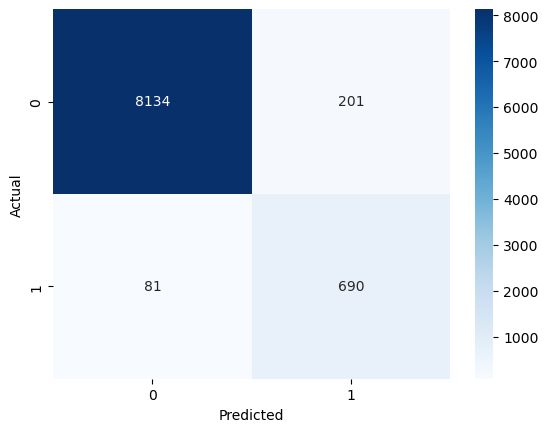

In [94]:
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import seaborn as sns

print("--- Final Model Performance on Test Data ---")
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"F1-Score: {f1:.4f}")


print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred))

print("\n--- Confusion Matrix ---")
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


Since, in this problem, higher recall is more important as we dont want to miss the actuall defaulters i.e the cost of false negative is much higher so we lower the threshold from 0.5 to 0.3.

In [99]:
y_probs = final_pipeline.predict_proba(X_test)[:,1]
y_pred_custom = (y_probs>0.3).astype(int)

In [100]:
print( classification_report(y_test,y_pred_custom,digits=3))

              precision    recall  f1-score   support

           0      0.992     0.970     0.981      8335
           1      0.738     0.912     0.816       771

    accuracy                          0.965      9106
   macro avg      0.865     0.941     0.898      9106
weighted avg      0.970     0.965     0.967      9106

